# PARTE 1: Exploración inicial y balance de clases

## 1.1. Importar librerías


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

## 1.2. Cargar cada CSV del corpus

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Rutas CSVs y JSONs
base = "/content/drive/MyDrive/tfg/corpusMentalRiskES/processed/"
paths = {
    "ED": {
        "csv": base + "ED/gold/gold_label.csv",
        "json": base + "ED/data/"
    },
    "Depression": {
        "csv": base + "Depress/gold/gold_label.csv",
        "json": base + "Depress/data/"
    },
    "Anxiety": {
        "csv": base + "Anxiety/gold/gold_label.csv",
        "json": base + "Anxiety/data/"
    }
}

# Leer los csv
df_anx = pd.read_csv(paths["Anxiety"]["csv"], sep="\t")
df_dep = pd.read_csv(paths["Depression"]["csv"], sep="\t")
df_ed = pd.read_csv(paths["ED"]["csv"], sep="\t")

,nick,bs,bc,rbs,rbc
0,subject1,1,0,1.0,0.0
1,subject10,0,1,0.4,0.6
2,subject100,1,0,1.0,0.0
3,subject101,1,0,0.5,0.5
4,subject102,1,0,0.5,0.5


## 1.3. Mostrar número de sujetos por partición

In [6]:
print("ED:", df_ed.shape[0])
print("Depresión:", df_dep.shape[0])
print("Ansiedad:", df_anx.shape[0])

ED: 335
Depresión: 499
Ansiedad: 500


## 1.4. Comprobar desbalanceo de clases

In [ ]:
def resumen_clases(df, nombre):
    print("====", nombre, "====")
    print(df['bs'].value_counts())
    print()

resumen_clases(df_anx, "Ansiedad")
resumen_clases(df_dep, "Depresión")
resumen_clases(df_ed, "Eating Disorders (ED)")

==== Ansiedad ====
bs
1    443
0     57
Name: count, dtype: int64

==== Depresión ====
bs
1    333
0    166
Name: count, dtype: int64

==== Eating Disorders (ED) ====
bs
0    192
1    143
Name: count, dtype: int64



**Ansiedad** -> muy desequilibrada

**Depresión** -> desequilibrada: doble de sujetos positivos respecto a negativos.

**ED** -> algo más equlibrada

## 1.5. Generar histogramas

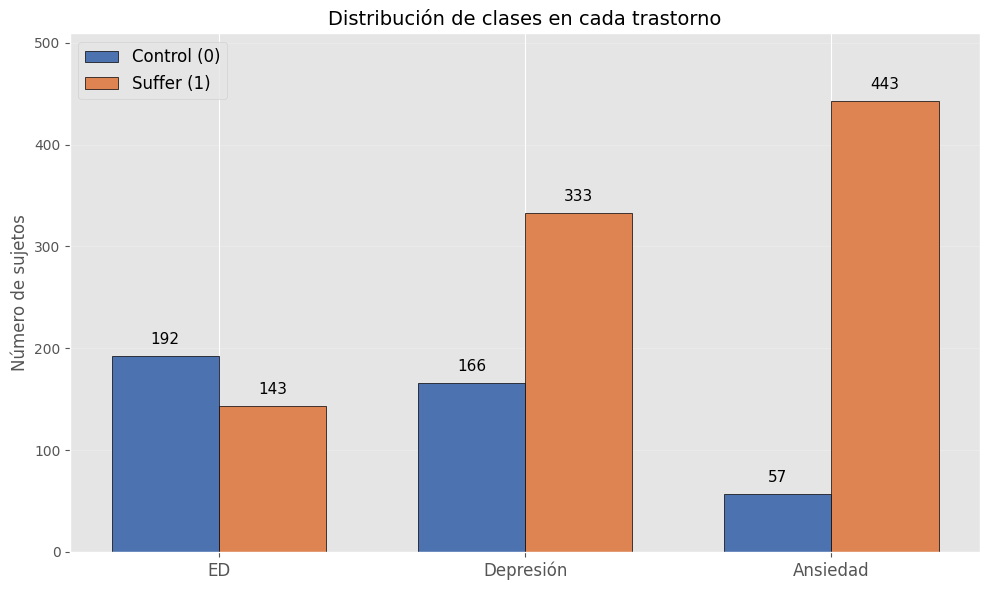

In [ ]:
# Obtener conteos
ed_counts = df_ed['bs'].value_counts()
dep_counts = df_dep['bs'].value_counts()
anx_counts = df_anx['bs'].value_counts()

# Nombres de trastornos
labels = ["ED", "Depresión", "Ansiedad"]

# Valores ordenados: para cada trastorno -> [control, suffer]
control_vals = [ed_counts[0], dep_counts[0], anx_counts[0]]
suffer_vals  = [ed_counts[1], dep_counts[1], anx_counts[1]]

x = np.arange(len(labels))         # posiciones base
width = 0.35                       # ancho de cada barra

plt.style.use('ggplot')  # estilo moderno

plt.figure(figsize=(10,6))

# Colores profesionales
color_control = "#4C72B0"  # azul suave
color_suffer  = "#DD8452"  # naranja suave

# Barras: control
bars1 = plt.bar(x - width/2, control_vals, width,
                label="Control (0)", color=color_control, edgecolor="black")

# Barras: suffer
bars2 = plt.bar(x + width/2, suffer_vals, width,
                label="Suffer (1)", color=color_suffer, edgecolor="black")

# Añadir valores encima de cada barra
for bar in bars1 + bars2:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + max(control_vals + suffer_vals)*0.02,
        str(yval),
        ha='center', va='bottom', fontsize=11
    )

# Configuración estética
plt.xticks(x, labels, fontsize=12)
plt.ylabel("Número de sujetos", fontsize=12)
plt.title("Distribución de clases en cada trastorno", fontsize=14)

plt.grid(axis='y', alpha=0.2)
plt.ylim(0, max(control_vals + suffer_vals) * 1.15)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

# PARTE 2: Análisis de número de mensajes por usuario

## 2.1. Funciones auxiliares

In [9]:
import json
from tqdm import tqdm

def cargar_json_messages(folder_path):
    """
    Devuelve un diccionario:
    { user_id : [lista_de_mensajes] }
    """
    mensajes = {}
    for filename in os.listdir(folder_path):
        if filename.endswith(".json"):
            user_id = filename.replace(".json", "")
            with open(os.path.join(folder_path, filename), "r", encoding="utf-8") as f:
                data = json.load(f)
                mensajes[user_id] = [m["message"] for m in data]
    return mensajes

def contar_mensajes_y_palabras(mensajes_user):
    """
    Devuelve un diccionario con:
    { user_id : (num_mensajes, num_palabras) }
    """
    stats = {}
    for user_id, mensajes in mensajes_user.items():
        num_mensajes = len(mensajes)
        num_palabras = sum(len(m.split()) for m in mensajes)
        stats[user_id] = (num_mensajes, num_palabras)
    return stats

## 2.2. Procesar número de mensajes y palabras de cada trastorno

In [10]:
def analizar_mensajes_trastorno(df, ruta_json):
    """
    Analiza el número de mensajes y palabras por usuario para un trastorno específico.

    Parámetros:
        df (DataFrame): dataframe con los usuarios y su etiqueta 'bs'.
        ruta_json (str): ruta a la carpeta con los archivos JSON de cada usuario.

    Devuelve:
        DataFrame: tabla con columnas
                   ['user_id', 'bs', 'num_mensajes', 'num_palabras'].
    """

    # Cargar mensajes
    mensajes = cargar_json_messages(ruta_json)

    # Contar mensajes y palabras
    stats = contar_mensajes_y_palabras(mensajes)

    # Crear dataframe intermedio
    datos = []
    for user_id, (num_mensajes, num_palabras) in stats.items():
        if user_id in df["nick"].values:
            etiqueta = int(df[df["nick"] == user_id]["bs"].iloc[0])
            datos.append([user_id, etiqueta, num_mensajes, num_palabras])

    df_stats = pd.DataFrame(datos, columns=["user_id", "bs", "num_mensajes", "num_palabras"])

    return df_stats

stats_anx = analizar_mensajes_trastorno(df_anx, paths["Anxiety"]["json"])
stats_dep = analizar_mensajes_trastorno(df_dep, paths["Depression"]["json"])
stats_ed = analizar_mensajes_trastorno(df_ed, paths["ED"]["json"])

,user_id,bs,num_mensajes,num_palabras
0,subject200,1,13,209
1,subject11,1,22,305
2,subject210,1,100,1979
3,subject158,1,13,178
4,subject320,1,100,1882


## 2.3. Resumir estadísticas

In [16]:
def resumir_stats_trastorno(df_stats):
    """
    Crea una tabla con:
    filas -> métricas
    columnas -> Control / Suffer / Total
    """
    # Separar grupos
    df_control = df_stats[df_stats["bs"] == 0]
    df_suffer  = df_stats[df_stats["bs"] == 1]

    resumen = {
        "Control": {
            "num_sujetos": len(df_control),
            "num_mensajes": df_control["num_mensajes"].sum(),
            "media_mensajes": df_control["num_mensajes"].mean(),
            "num_palabras": df_control["num_palabras"].sum(),
            "media_palabras": df_control["num_palabras"].mean(),
        },
        "Suffer": {
            "num_sujetos": len(df_suffer),
            "num_mensajes": df_suffer["num_mensajes"].sum(),
            "media_mensajes": df_suffer["num_mensajes"].mean(),
            "num_palabras": df_suffer["num_palabras"].sum(),
            "media_palabras": df_suffer["num_palabras"].mean(),
        },
        "Total": {
            "num_sujetos": len(df_stats),
            "num_mensajes": df_stats["num_mensajes"].sum(),
            "media_mensajes": df_stats["num_mensajes"].mean(),
            "num_palabras": df_stats["num_palabras"].sum(),
            "media_palabras": df_stats["num_palabras"].mean(),
        }
    }

    # Convertir diccionario a DataFrame
    tabla_resumen = pd.DataFrame(resumen)

    return tabla_resumen.round(2)

display(resumir_stats_trastorno(stats_anx))
print("\n")
display(resumir_stats_trastorno(stats_dep))
print("\n")
display(resumir_stats_trastorno(stats_ed))

,Control,Suffer,Total
num_sujetos,57.00,443.00,500.00
num_mensajes,2222.00,16293.00,18515.00
media_mensajes,38.98,36.78,37.03
num_palabras,31248.00,276853.00,308101.00
media_palabras,548.21,624.95,616.20


,Control,Suffer,Total
num_sujetos,166.00,333.00,499.00
num_mensajes,6287.00,11083.00,17370.00
media_mensajes,37.87,33.28,34.81
num_palabras,84435.00,159868.00,244303.00
media_palabras,508.64,480.08,489.59


,Control,Suffer,Total
num_sujetos,192.00,143.00,335.00
num_mensajes,6586.00,3913.00,10499.00
media_mensajes,34.30,27.36,31.34
num_palabras,93614.00,64667.00,158281.00
media_palabras,487.57,452.22,472.48
